In [19]:
%pip install -r requirements.txt
import matplotlib.pyplot as plt
from tqdm import tqdm


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from src.variables import *
from src.aux_func import *
from src.int_no_approx import *

In [33]:
import numpy as np

from scipy.ndimage import gaussian_filter1d
import torch
import pywt
import torchquad

def Ffun(si, li, sf, lf, y):
    sf_lf_fact = factorial(sf + lf)
    si_fact = factorial(si)

    exponent = 3*(si - sf) + 2*li - lf + 2
    y_power = y**(2*(si - sf) + li - lf)

    y_sq = y**2
    L1 = L_mod(sf + lf, (si - sf + li - lf), y_sq / torch.tensor(8, dtype=dtype, device=device))
    L2 = L_mod(sf, (si - sf), y_sq / torch.tensor(8, dtype=dtype, device=device))

    exp_term = torch.exp(-y_sq / torch.tensor(8, dtype=dtype, device=device))

    return (sf_lf_fact / si_fact) * (1 / 2**exponent) * y_power * L1 * L2 * exp_term

def Ip1(si, li, sf, lf, y):
    term1 = 2 * Ffun(si, li, sf, lf + 1, y)
    term2 = (si + li) * Ffun(si, li - 1, sf, lf, y)
    return (-1j) * torch.sqrt(torch.tensor(2.0, device=device)) * (term1 + term2)

def Im1(si, li, sf, lf, y):
    term1 = 2 * Ffun(si, li + 1, sf, lf, y)
    term2 = (sf + lf) * Ffun(si, li, sf, lf - 1, y)
    return (-1j) * torch.sqrt(torch.tensor(2.0, device=device)) * (term1 + term2)

# Регуляризация
eps = torch.tensor(1e-30)

# Члены суммы по проекциям спина фотона на ось z в S_fi
def TT_wide(si, li, pzi, sf, lf, pzf, y):
   
    term1 = Im1(si, li, sf, lf, y) 
    term2 = - rho_H *(pzi + pzf)* Ffun(si, li, sf, lf, y) 
    term3 = Ip1(si, li, sf, lf, y) 

    return torch.stack([term1, term2, term3])


def Sfi_wide(si, li, pzi, sf, lf, pzf, kp, phi_k, lambda_, t_in, t_out):
    # Ensure all inputs are tensors and on the correct device
    # Convert scalar inputs to tensors if they aren't already

    si_t = torch.tensor(si, dtype=dtype, device=device) if not isinstance(si, torch.Tensor) else si.clone().detach()
    li_t = torch.tensor(li, dtype=dtype, device=device) if not isinstance(li, torch.Tensor) else li.clone().detach()
    sf_t = torch.tensor(sf, dtype=dtype, device=device) if not isinstance(sf, torch.Tensor) else sf.clone().detach()
    lf_t = torch.tensor(lf, dtype=dtype, device=device) if not isinstance(lf, torch.Tensor) else lf.clone().detach()
    lambda_t = torch.tensor(lambda_, dtype=dtype, device=device) if not isinstance(lambda_, torch.Tensor) else lambda_.clone().detach()
    # Pre-calculate common terms for efficiency
    pzi_minus_pzf = pzi - pzf
    kp_sq_plus_pzm_sq = kp**2 + pzi_minus_pzf**2

    sqrt1 = torch.sqrt((2**(torch.abs(li_t) + 1)) / (torch.pi * rho_H**2) * factorial(si_t) / factorial(si_t + li_t))
    sqrt2 = torch.sqrt((2**(torch.abs(lf_t) + 1)) / (torch.pi * rho_H**2) * factorial(sf_t) / factorial(sf_t + lf_t))

    photon_norm = 1 / torch.sqrt(2 * torch.sqrt(kp_sq_plus_pzm_sq))
    # Общий префактор
    prefactor = -(2 * torch.pi)**3 * 1j * photon_norm * sqrt1 * sqrt2 * (q * rho_H) / (2 * m)
    exp_term = torch.exp(1j * (li_t - lf_t) * phi_k)
    # Вычисление суммы

    total_sum = torch.zeros_like(kp, dtype=torch.complex128, device=device)
    # Calculate the angle for WignerD
    angle_for_wigner_d = torch.atan2(kp, pzi_minus_pzf)
    # Convert lambda_ to int for wigner_d_matrix_j1_torch
    lambda_int = int(lambda_t.item()) # Use .item() to get Python scalar from 0-dim tensor
    for sigma_pol in range(-1, 2):  # sigma_pol = -1, 0, 1
        i_power = (1j)**(sigma_pol - li_t + lf_t)
        # Get the Wigner D value using the new PyTorch function
        wigner_d_val = wigner_d_matrix_j1_torch(sigma_pol, lambda_int, angle_for_wigner_d)
        # Get the corresponding element from TT
        # Ensure si, li, sf, lf are passed as Python ints to TT_wide's internal functions
        tt_elements = TT_wide(int(si_t.item()), int(li_t.item()), pzi, int(sf_t.item()), int(lf_t.item()), pzf, kp * rho_H)
        tt_element = tt_elements[sigma_pol + 1]
        # Add to the sum
        total_sum += i_power * wigner_d_val * tt_element
    result = prefactor * exp_term * total_sum
    return result

# Функция для сглаживания быстро осциллирующих функций (выдаёт "среднее значение")
def apply_savgol_filter_to_tensor(data_tensor, sigma):
    data_np = data_tensor.clone().detach().cpu().numpy()
    smoothed_np = gaussian_filter1d(data_np, sigma=sigma)
    return torch.as_tensor(smoothed_np, dtype=data_tensor.dtype, device=data_tensor.device)


# ------------------ S_fi -------------------

# Сглаженный матричный элемент
# Только для визуализации - не использовать в сглаженных вероятностях
def Sfi_wide_sm(si, li, pzi, sf, lf, pzf, kp, phi_k, lambda_, t_in, t_out):
    return apply_savgol_filter_to_tensor(
        Sfi_wide(si, li, pzi, sf, lf, pzf, kp, phi_k, lambda_, t_in, t_out), 20)


# ------------------ Differential Probability -------------------

# Сглаженная дифференциальная вероятность: d W / d pzf
def dW_dpzf_pol_wide_sm(si, li, pzi, sf, lf, pzf, lambda_, t_in, t_out, kp_max):
    measure_factor = (2 * torch.pi)**-3
    gl = torchquad.GaussLegendre()

    def integrand(x):
        # Используем clone().detach() для входных данных
        x_tensor = x.clone().detach() if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)
        return apply_savgol_filter_to_tensor(x_tensor * torch.abs(Sfi_wide(si, li, pzi, sf, lf, pzf, x_tensor, 0, lambda_, t_in, t_out))**2, 20)

    int_result = gl.integrate(integrand, dim=1, N=3, integration_domain=[[1e-10, float(kp_max)]])
    return 2 * torch.pi * measure_factor * int_result

def dW_dpzf_unpol_wide_sm(si, li, pzi, sf, lf, pzf, t_in, t_out, kp_max):
    return dW_dpzf_pol_wide_sm(si, li, pzi, sf, lf, pzf, 1, t_in, t_out, kp_max) + dW_dpzf_pol_wide_sm(si, li, pzi, sf, lf, pzf, -1, t_in, t_out, kp_max)


# ------------------ Full Probability -------------------

def full_prob(si, li, pzi, sf, lf, t_in, t_out, kp_max, pzf_min):
    gl = torchquad.GaussLegendre()

    def integrand(pzf_batch):  # pzf_batch has shape [N, 1]
        # Распаковать батч:
        pzf_batch = pzf_batch.view(-1)  # теперь [N]

        # Вернуть батч результатов:
        results = torch.stack([
            dW_dpzf_unpol_wide_sm(si, li, pzi, sf, lf, pzf_i.item(), t_in, t_out, kp_max)
            for pzf_i in pzf_batch
        ])
        return results  # shape [N]

    result = gl.integrate(integrand, dim=1, N=3, integration_domain=[[pzf_min, pzi]]) # Верхний предел интегрирования - pzi
    return result

/tmp/ipykernel_13945/3450822691.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pzmin_arr = [torch.tensor(0), torch.tensor(pzi - 1e-3), torch.tensor(pzi - 2e-5)]
Integrating: 100%|██████████| 80/80 [14:05<00:00, 10.57s/it]


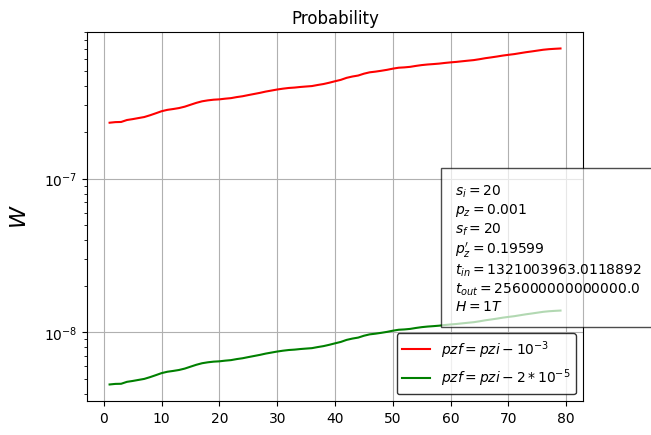

In [30]:
full_prob_li_lf_1_pzmin1 = []
full_prob_li_lf_1_pzmin2 = []
full_prob_li_lf_1_pzmin3 = []

pzmin_arr = [torch.tensor(0), torch.tensor(pzi - 1e-3), torch.tensor(pzi - 2e-5)]


lf_arr = [i for i in range(1, 81)]


darkbrown = '#654321'
darkorange = '#FF8C00'

plt.figure()
for lf in tqdm(lf_arr, desc="Integrating", colour="green"):
    # full_prob_li_lf_1_pzmin1.append(full_prob(si, lf + 1, pzi, sf, lf, t_in, t_out, kp_max, pzmin_arr[0]))
    full_prob_li_lf_1_pzmin2.append(full_prob(si, lf + 1, pzi, sf, lf, t_in, t_out, kp_max, pzmin_arr[1]))
    full_prob_li_lf_1_pzmin3.append(full_prob(si, lf + 1, pzi, sf, lf, t_in, t_out, kp_max, pzmin_arr[2]))
# plt.plot(lf_arr, full_prob_li_lf_1_pzmin1, label='$pzf = 0', color = 'black')
plt.plot(lf_arr, full_prob_li_lf_1_pzmin2, label='$pzf = pzi - 10^{{-3}}$', color = 'red')
plt.plot(lf_arr, full_prob_li_lf_1_pzmin3, label='$pzf = pzi - 2 * 10^{{-5}}$', color = 'green')

#plt.xlabel("$k_{\perp} (eV)$", fontsize = 16)
#plt.xticks(k_ticks, k_ticks_ev, rotation=0)
plt.yscale("log")
plt.ylabel(r"$W$", fontsize = 16, labelpad=10)
plt.title("Probability")
plt.grid()
label = f"$s_i={si}$\n$p_z={pzi}$\n$s_f={sf}$\n$p_z'={pzf}$\n$t_{{in}}={t_in}$\n$t_{{out}}={t_out}$\n$H = 1 T$"
plt.figtext(0.7, 0.3, label, bbox={'facecolor': 'white', 'alpha': 0.7, 'pad': 10})

legend = plt.legend(frameon=True)

# Настроим цвет фона и рамки легенды
legend.get_frame().set_facecolor('white')      # белый фон
legend.get_frame().set_edgecolor('black')      # черная рамка
legend.get_frame().set_linewidth(1.0)          # толщина рамки

plt.show()

In [ ]:
HtoHc = torch.tensor(1, dtype=dtype, device=device) # Величина магнитного поля: 2.27e-10 -> 1T
rho_H = 2.0 / torch.sqrt(HtoHc) # Магнитная длина: для H = 1 T магнитная длина 132 744 комптоновских длин волн или 5.12e-8 m = 0.512 nm
kp_max = 10 / rho_H
F0 = torch.tensor(7.57e-8, dtype=dtype, device=device) # 100 MV / m
pzf_min = 0
pzi = torch.tensor(1e-3, dtype=dtype, device=device)
pzf_max = pzi

si = 20
li = 1
sf = 20
lf = 1
t_in = 100 / F0
t_out = torch.tensor(2.56e14, dtype=dtype, device=device) # 100 m

full_prob_li_lf_1_Hc = []
full_prob_li_lf_2_Hc = []
full_prob_li_lf_3_Hc = []
full_prob_li_lf_4_Hc = []
full_prob_li_lf_5_Hc = []
full_prob_li_lf_6_Hc = []
full_prob_li_lf_7_Hc = []
full_prob_si_sf_1_li_lf_1_Hc = []
full_prob_si_sf_2_li_lf_0_Hc = []
full_prob_si_sf_1_li_lf_4_Hc = []
full_prob_si_sf_2_li_lf_3_Hc = []
full_prob_si_sf_1_li_lf_0_Hc = []
full_prob_si_sf_2_li_lf_m1_Hc = []

#lf_arr = [i for i in range(1, 80)]
lf_arr = [i for i in range(1, 81)]

HtoHc = torch.tensor(1e-2, dtype=dtype, device=device) # Величина магнитного поля: 2.27e-10 -> 1T
rho_H = 2.0 / torch.sqrt(HtoHc)

darkbrown = '#654321'
darkorange = '#FF8C00'

plt.figure()
for lf in tqdm(lf_arr, desc="Integrating", colour="green"):
    full_prob_li_lf_1_Hc.append(full_prob(si, lf + 1, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_li_lf_2_Hc.append(full_prob(si, lf + 2, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_li_lf_3_Hc.append(full_prob(si, lf + 3, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_li_lf_4_Hc.append(full_prob(si, lf + 4, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_li_lf_5_Hc.append(full_prob(si, lf + 5, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_li_lf_6_Hc.append(full_prob(si, lf + 6, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_li_lf_7_Hc.append(full_prob(si, lf + 7, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_si_sf_1_li_lf_1_Hc.append(full_prob(sf+1, lf + 1, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_si_sf_2_li_lf_0_Hc.append(full_prob(sf+2, lf, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_si_sf_1_li_lf_4_Hc.append(full_prob(sf+1, lf + 4, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_si_sf_2_li_lf_3_Hc.append(full_prob(sf+2, lf + 3, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_si_sf_1_li_lf_0_Hc.append(full_prob(sf+1, lf, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
    full_prob_si_sf_2_li_lf_m1_Hc.append(full_prob(sf+2, lf - 1, pzi, sf, lf, t_in, t_out, kp_max, pzf_min))
plt.plot(lf_arr, full_prob_li_lf_1_Hc, label='$li - lf = 1$', color = 'black')
plt.plot(lf_arr, full_prob_li_lf_2_Hc, label='$li - lf = 2$', color = 'red')
plt.plot(lf_arr, full_prob_li_lf_3_Hc, label='$li - lf = 3$', color = 'blue')
plt.plot(lf_arr, full_prob_li_lf_4_Hc, label='$li - lf = 4$', color = 'lightgreen')
plt.plot(lf_arr, full_prob_li_lf_5_Hc, label='$li - lf = 5$', color = darkbrown)
plt.plot(lf_arr, full_prob_li_lf_6_Hc, label='$li - lf = 6$', color = 'magenta')
plt.plot(lf_arr, full_prob_li_lf_7_Hc, label='$li - lf = 7$', color = darkorange)
plt.plot(lf_arr, full_prob_si_sf_1_li_lf_1_Hc, label='$si - sf = 1, li - lf = 1$', color = 'red', linestyle = '--')
plt.plot(lf_arr, full_prob_si_sf_2_li_lf_0_Hc, label='$si - sf = 2, li - lf = 0$', color = 'red', linestyle = '-.')
plt.plot(lf_arr, full_prob_si_sf_1_li_lf_4_Hc, label='$si - sf = 1, li - lf = 4$', color = darkbrown, linestyle = '--')
plt.plot(lf_arr, full_prob_si_sf_2_li_lf_3_Hc, label='$si - sf = 2, li - lf = 3$', color = darkbrown, linestyle = '-.')
plt.plot(lf_arr, full_prob_si_sf_1_li_lf_0_Hc, label='$si - sf = 1, li - lf = 0$', color = 'black', linestyle = '-.')
plt.plot(lf_arr, full_prob_si_sf_2_li_lf_m1_Hc, label='$si - sf = 2, li - lf = -1$', color = 'blue', linestyle = '-.')
#plt.xlabel("$k_{\perp} (eV)$", fontsize = 16)
#plt.xticks(k_ticks, k_ticks_ev, rotation=0)
plt.yscale("log")
plt.ylabel(r"$W$", fontsize = 16, labelpad=10)
plt.title("Probability")
plt.grid()
#label = f"$s_i={si}$\n$p_z={pzi}$\n$s_f={sf}$\n$p_z'={pzf}$\n$t_{{in}}={t_in}$\n$t_{{out}}={t_out}$\n$H = H_{{\text{{c}}}}$"
#plt.figtext(0.7, 0.3, label, bbox={'facecolor': 'white', 'alpha': 0.7, 'pad': 10})

legend = plt.legend(frameon=True)

# Настроим цвет фона и рамки легенды
# legend.get_frame().set_facecolor('white')      # белый фон
# legend.get_frame().set_edgecolor('black')      # черная рамка
# legend.get_frame().set_linewidth(1.0)          # толщина рамки

plt.show()

Integrating:  48%|████▊     | 38/80 [01:23<01:54,  2.72s/it]